<a href="https://colab.research.google.com/github/Matheus0820/Aprendizado-de-Maquina/blob/main/unidade01/codes/CNN_na_base_de_dados_da_Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Usando uma CNN para prever a classificação de peças de roupas

Aprendizado de Máquina 26.1

**Aluno:** Matheus Ramos Ferreira da Silva.

## Importando dados

In [4]:
# Importanto bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Capturando dados do feshion MNIST e separando em treino e teste
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Tamanho de dados captados
print(f'O conjunto de treino possui {X_train.shape[0]} imagens e o conjunto de teste possui {X_test.shape[0]} imagens.')



O conjunto de treino possui 60000 imagens e o conjunto de teste possui 10000 imagens.


## Visualizando alguns dados

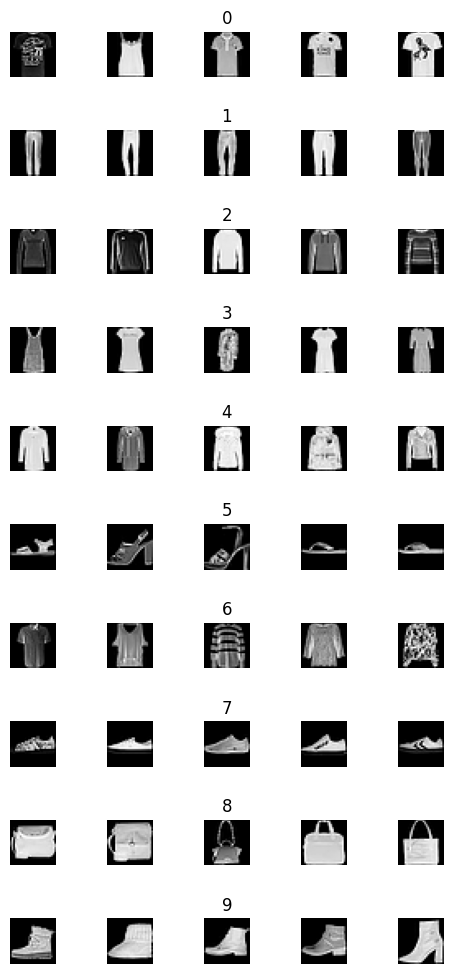

In [6]:
# Importando bibliotecas importantes
import random
import time

# Selecionando semente do random
random.seed(time.time())

num_of_samples = []
cols = 5
num_classes = 10

# Criando plotagem dos dados
fig, axes = plt.subplots(nrows = num_classes, ncols = cols, figsize = (5, 10))
fig.tight_layout()

for i in range(cols):
    for j in range(num_classes):
      x_idx = X_train[y_train == j]
      axes[j][i].imshow(x_idx[random.randint(0, (len(x_idx) - 1)), :, :], cmap = plt.get_cmap('gray'))
      axes[j][i].axis('off')

      if i == 2:
        axes[j][i].set_title(str(j))
        num_of_samples.append(len(x_idx))

## Distribuição das classes de roupas nas amostras de treinamento




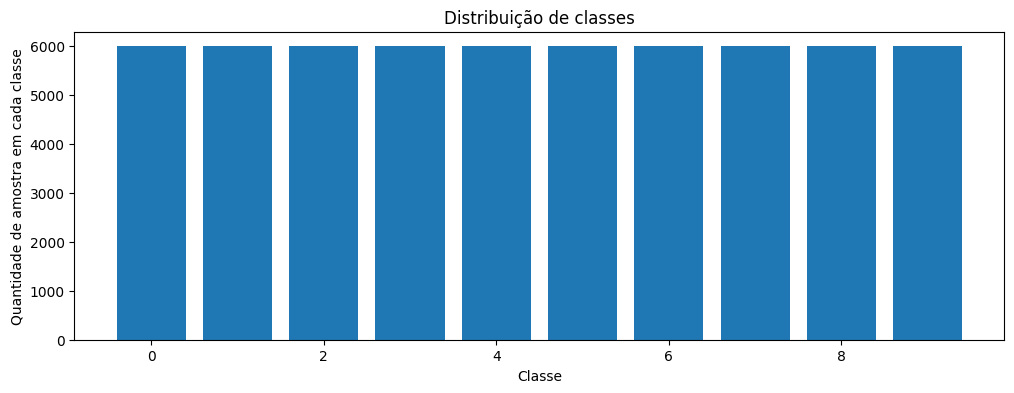

In [8]:
# Plotando a distribuição das classe de roupa nas amostras de treinamento
plt.figure(figsize = (12, 4))
plt.bar(range(0, num_classes), num_of_samples)
plt.title('Distribuição de classes')
plt.xlabel('Classe')
plt.ylabel('Quantidade de amostra em cada classe')
plt.show()

## Normalização e tratamento dos dados

In [9]:
# Transformando classe para o formato One-Hot Encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_teste = tf.keras.utils.to_categorical(y_test, num_classes)

# Normalizando valores das colunas de X de teste e treinamento para valores entre 0 e 1
X_train = X_train / 255
X_test = X_test / 255

## Treinamento
### Rede neural

In [10]:
# Criando a estrutura da rede para o treinamento
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(30, (5, 5), input_shape = (28, 28, 1), activation = 'relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size = (2, 2)))
model.add(tf.keras.layers.Conv2D(15, (3, 3), activation = 'relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size = (2, 2)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(500, activation = 'relu'))
model.add(tf.keras.layers.Dense(num_classes, activation = 'softmax'))
model.compile(tf.keras.optimizers.Adam(learning_rate = 0.01), loss = 'categorical_crossentropy', metrics = ['accuracy'])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 30)     │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 15)     │         4,065 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 15)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 375)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │       188,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,855 (772.87 KB)

 Trainable params: 197,855 (772.87 KB)

 Non-trainable params: 0 (0.00 B)

None


### Treinando a rede neural

In [12]:
# Trinando a rede criada
history = model.fit(X_train, y_train, epochs = 10, validation_split = 0.1, batch_size = 400, verbose = 1, shuffle = 1)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 32s 224ms/step - accuracy: 0.7879 - loss: 0.5784 - val_accuracy: 0.8505 - val_loss: 0.3994
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 42s 232ms/step - accuracy: 0.8715 - loss: 0.3492 - val_accuracy: 0.8760 - val_loss: 0.3281
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 40s 226ms/step - accuracy: 0.8863 - loss: 0.3053 - val_accuracy: 0.8783 - val_loss: 0.3297
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 40s 217ms/step - accuracy: 0.8956 - loss: 0.2763 - val_accuracy: 0.8870 - val_loss: 0.2976
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 29s 213ms/step - accuracy: 0.9022 - loss: 0.2605 - val_accuracy: 0.8927 - val_loss: 0.2836
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 42s 221ms/step - accuracy: 0.9093 - loss: 0.2427 - val_accuracy: 0.8945 - val_loss: 0.2981
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 41s 224ms/step - accuracy: 0.9162 - loss: 0.2227 - val_accuracy: 0.8890 - val_loss: 0.3034
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 40s 215ms/step - accuracy: 0.9183 - loss: 0

## Avalindando o modelo treinado

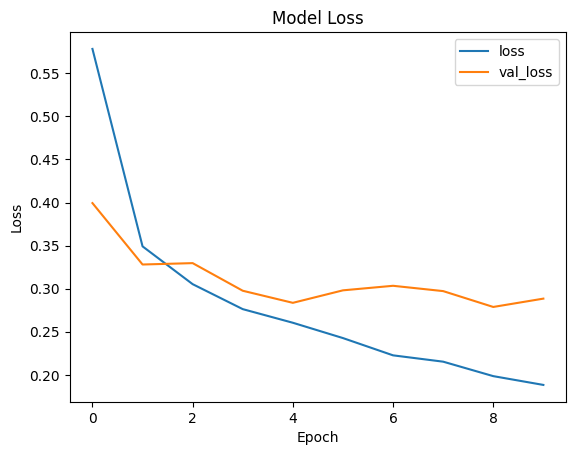

In [13]:
# Plotando o LOSS
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

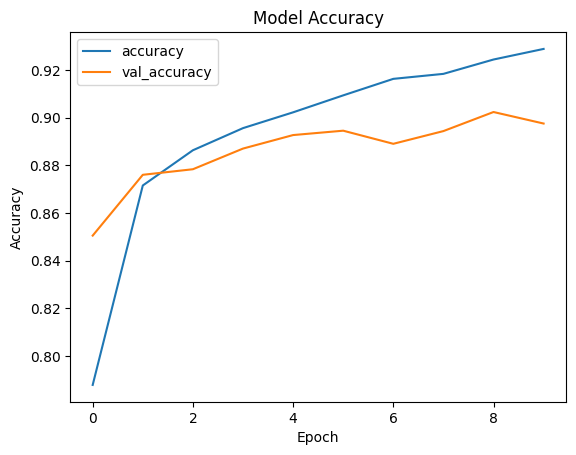

In [14]:
# Plotando o valor da acurácia
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

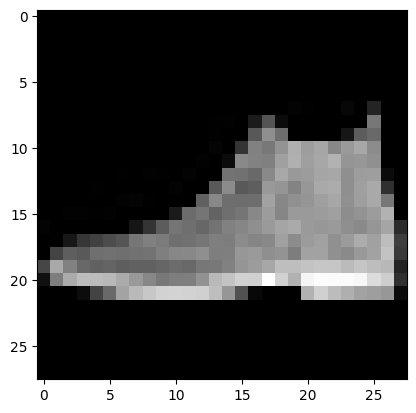

In [15]:
# Aplicando modelo em uma imagem da base de dados
img = X_test[0]
img = (np.expand_dims(img, 0))

# Plotando imagem
plt.imshow(img[0], cmap = plt.get_cmap('gray'))
plt.show()

In [19]:
# Tratando imagem
img = img / 255
img = img.reshape(1, 28, 28, 1)

# Jogando no modelo
predictions = model.predict(img)
print(f"Previsão para cada classe: {str(predictions)}")
predictions = np.argmax(predictions, axis = 1)
print("\n")
print("="*30)
print(f"Previsão - Classe prevista: {str(predictions)}")
print("="*30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Previsão para cada classe: [[1.2523879e-04 1.4493148e-06 3.9480921e-05 3.7523612e-05 1.0505037e-06
  9.7057557e-01 2.8184371e-03 2.4259131e-02 1.8351056e-03 3.0704477e-04]]


Previsão - Classe prevista: [5]


In [21]:
# Precisão do modelo
score = model.evaluate(X_test, y_teste, verbose = 1)
print(type(score))
print("\nErro do teste (LOSS): ", score[0])
print("Acurácia: ", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8972 - loss: 0.3146
<class 'list'>

Erro do teste (LOSS):  0.3145653009414673
Acurácia:  0.8971999883651733
